# 4. The Colina benchmark polymers: initialize, export, analyze

The six amorphous polymers of the Abbott, Hart and Colina (2013) benchmark
set, as FlowerMD presets: atactic polystyrene (PS), atactic PMMA, PET,
bisphenol-A polycarbonate (PC), polyetherimide (PEI, Ultem) and PIM-1.
Each is initialized with the frozen all-atom PhantomWalk protocol at its
experimental room-temperature density, minimized with Sage 2.3.0, and
exported for analysis. The second half is a starting point for structural
characterization with MDAnalysis and freud.

**What these structures are.** They are initialized and minimized, not
equilibrated. Every stage runs at constant volume, so the density is the
target by construction, and chain dimensions and the structure factor
describe the initializer's output. Properties of the melt itself (density,
Rg, WAXS) need NPT molecular dynamics after this hand-off; these numbers are
the reference such a run starts from.

Each system has about 3,300 atoms. The whole notebook takes a few minutes on
a GPU and roughly 10 to 20 minutes on a CPU.

In [1]:
import hoomd

# GPU if one is visible, otherwise CPU. OpenMM follows the same choice.
try:
    DEVICE = hoomd.device.GPU()
    OPENMM_PLATFORM = "CUDA"
except Exception:
    DEVICE = hoomd.device.CPU()
    OPENMM_PLATFORM = "CPU"
print(DEVICE, OPENMM_PLATFORM)

<hoomd.device.CPU object at 0x707d0bf123c0> CPU


In [2]:
# The frozen all-atom PhantomWalk protocol, written out explicitly.
PROTOCOL = dict(
    bonded="uff", A=1250.0, gamma=200.0, kT=1.0, r_cut=3.5, bonded_scale=30.0,
    epsilon_weighting=True, protect_stereochemistry=True, stereo_k=30000.0,
)
RUN = dict(
    dpd_min_steps=3500, dpd_chunk=500, dpd_max_steps=40000, energy_tol=0.02,
    consecutive=2, dpd_samples_per_chunk=5, fire_steps=100, fire_dt=0.001,
    require_convergence=False,
)
DT = 0.001

In [3]:
from pathlib import Path

# Everything this notebook writes goes here.
OUT = Path("outputs/4-colina-polymers")
OUT.mkdir(parents=True, exist_ok=True)

# True saves a DPD + FIRE trajectory (one GSD frame every 250 steps) for a
# movie; False writes only the starting frame.
SAVE_TRAJECTORY = True


def writers(folder):
    """Simulation keywords that put the GSD trajectory and log in `folder`."""
    folder.mkdir(parents=True, exist_ok=True)
    return dict(
        gsd_file_name=str(folder / "dpd.gsd"),
        gsd_write_freq=250 if SAVE_TRAJECTORY else 10**9,
        log_file_name=str(folder / "log.txt"),
    )

## The systems

`(preset, preset options, repeats per chain, chains, placement unit)`.
Densities are the presets' `reference_density` (g/cm³); the residue names of
the exported files are in the last column.

Four of the six are placed as whole rigid chains (`unit="chain"`):

* **PS and PMMA** have backbone stereocenters spanning two repeats (see
  notebook 2).
* **PEI and PIM-1** have large repeats. Placing each repeat on its own
  lattice site leaves junction bonds longer than half of these ~35 Å boxes
  (up to 24 Å), and HOOMD measures a bond to the nearest image. For PIM-1,
  a ladder polymer with two bonds per junction, rings then close through a
  periodic image: those molecules can never be made whole, DPD cannot relax
  them, and Sage removes ~3,500 ε/atom. PEI with repeat placement minimizes
  with a bond stretched to 2.9 Å (~7,000 ε/atom removed). With whole chains
  both hand off cleanly (3 to 5 ε/atom, all bonds ≤ 1.6 Å). The exporter
  warns whenever a molecule closes a ring through the box.

PIM-1's DPD reaches the 40,000-step cap without the energies becoming
stationary; its coordinates still minimize cleanly.

In [4]:
from flowermd.library import PET, PEI, PIM1, PMMA, Polycarbonate, PolyStyrene

CHEMISTRIES = {
    #        preset          options                                   n    chains unit      residues
    "PS":    (PolyStyrene,   dict(tacticity="atactic", seed=11),       20,  10,  "chain"),   # PSR/PSS
    "PMMA":  (PMMA,          dict(tacticity="atactic", seed=11),       20,  10,  "chain"),   # PMR/PMS
    "PET":   (PET,           dict(),                                   15,  10,  "repeat"),  # ETP
    "PC":    (Polycarbonate, dict(),                                   10,  10,  "repeat"),  # BPC
    "PEI":   (PEI,           dict(),                                    6,   8,  "chain"),   # PEI
    "PIM-1": (PIM1,          dict(),                                    8,   8,  "chain"),   # PIM
}
for name, (preset, *_ ) in CHEMISTRIES.items():
    print(f"{name:>6}: {preset.reference_density} g/cm3")

    PS: 1.04 g/cm3
  PMMA: 1.18 g/cm3
   PET: 1.33 g/cm3
    PC: 1.2 g/cm3
   PEI: 1.27 g/cm3
 PIM-1: 1.06 g/cm3


## Initialize, minimize and export each polymer

Same steps as notebooks 1 and 2, in a loop. Each polymer gets a folder
`outputs/4-colina-polymers/<name>/` with `placement.pdb`, `initialized.pdb`,
`minimized.pdb` (use this one), `dpd.dcd`, the PyMOL scripts `movie.pml` and
`minimized.pml`, and `record.json`.

In [5]:
from phantomwalk.all_atom import (
    flush_trajectory, frame_positions, residue_topology, write_pdb, write_trajectory,
)
from phantomwalk.all_atom.visualization import write_pymol_script


def export(folder, sim, ff, minimized_a):
    """Write the three stages, the DPD trajectory and the PyMOL scripts."""
    top = residue_topology(sim.system.system, box_a=ff.frame.configuration.box[:3])
    initialized_a = sim.final_positions() * 10
    write_pdb(top, frame_positions(ff.frame), folder / "placement.pdb")
    write_pdb(top, initialized_a, folder / "initialized.pdb")
    write_pdb(top, minimized_a, folder / "minimized.pdb")
    flush_trajectory(sim)
    # FIRE's last steps rarely land on the GSD period; append the final frame
    write_trajectory(top, folder / "dpd.gsd", folder / "dpd.dcd",
                     append_positions_a=initialized_a)
    write_pymol_script(folder / "initialized.pdb", folder / "movie.pml",
                       trajectory=folder / "dpd.dcd")
    write_pymol_script(folder / "minimized.pdb", folder / "minimized.pml")
    return top

import time

import numpy as np
import unyt as u
from flowermd.library import AllAtomDPD, AllAtomLattice, AllAtomPhantomWalk
from phantomwalk.all_atom import sage_handoff

summary = {}
for name, (preset, options, n, chains, unit) in CHEMISTRIES.items():
    started = time.perf_counter()
    folder = OUT / name
    polymer = preset(lengths=n, num_mols=chains, **options)
    system = AllAtomLattice(polymer, density=preset.reference_density * u.g / u.cm**3,
                            unit=unit, seed=11)
    ff = AllAtomDPD(system.system, **PROTOCOL)
    sim = AllAtomPhantomWalk.from_system(system, forcefield=ff, dt=DT, device=DEVICE,
                                         seed=11, **writers(folder))
    record = sim.run_initialization(**RUN)
    box_a = np.asarray(ff.frame.configuration.box[:3])
    handoff, minimized_a = sage_handoff(sim.to_compound(), box_a / 10,
                                        platform=OPENMM_PLATFORM)
    sim.write_record(folder / "record.json")
    top = export(folder, sim, ff, minimized_a)
    stereo = record["stereochemistry"] or {}
    summary[name] = dict(
        atoms=record["n_particles"], box_a=box_a[0], dpd_steps=record["dpd_steps"],
        converged=record["dpd_converged"],
        stereo=stereo.get("post_fire", {}).get("passed", "-"),
        removed=handoff["energy_removed_sage_epsilon_atom"],
        residues=sorted(set(top.resnames)), wall_s=time.perf_counter() - started,
    )
    print(f"{name}: done in {summary[name]['wall_s']:.0f} s")

2026-09-24 14:42:04,511 - mbuild.compound - WARNING - Compound.box.lengths < Compound.boundingbox.lengths. There may be particles outside of the defined simulation box.


*Warning*: dihedral.harmonic: specified K <= 0


*Warning*: dihedral.harmonic: specified K <= 0


*Warning*: dihedral.harmonic: specified K <= 0


*Warning*: dihedral.harmonic: specified K <= 0


...

*Warning*: dihedral.harmonic: specified K <= 0


*Warning*: dihedral.harmonic: specified K <= 0


*Warning*: dihedral.harmonic: specified K <= 0


*Warning*: dihedral.harmonic: specified K <= 0


PIM-1: done in 133 s


In [6]:
print(f"{'':>6} {'atoms':>6} {'box A':>6} {'DPD steps':>9} {'stationary':>10} "
      f"{'stereo ok':>9} {'removed eps/atom':>16}  residues")
for name, s in summary.items():
    print(f"{name:>6} {s['atoms']:6d} {s['box_a']:6.1f} {s['dpd_steps']:9d} {str(s['converged']):>10} "
          f"{str(s['stereo']):>9} {s['removed']:16.2f}  {'/'.join(s['residues'])}")

        atoms  box A DPD steps stationary stereo ok removed eps/atom  residues
    PS   3220   32.2     17500       True      True             3.74  PSR/PSS
  PMMA   3020   30.4      9000       True      True             5.53  PMR/PMS
   PET   3320   33.0     19000       True         -             5.28  ETP
    PC   3320   32.8     11000       True         -             3.91  BPC
   PEI   3328   33.4     11000       True         -             4.41  PEI
 PIM-1   3552   35.9     40000      False      True             3.33  PIM


## Look at a structure or the DPD movie

Pick any of the six. `color="chainname"` gives one color per chain;
`"resname"` shows PS and PMMA tacticity.

In [7]:
from phantomwalk.all_atom.visualization import save_gif, show_movie, show_structure

VIEW = "PIM-1"
show_structure(OUT / VIEW / "minimized.pdb")

In [8]:
movie = (show_movie(OUT / VIEW / "initialized.pdb", OUT / VIEW / "dpd.dcd")
         if SAVE_TRAJECTORY else None)
movie

/home/joelaforet/miniconda3/envs/phantomwalk-all-atom/lib/python3.12/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


## Analysis: load the structures

`universe(pdb)` is `MDAnalysis.Universe(pdb)`: atoms carry element and mass,
residues are monomers, segments are chains, and bonds come from CONECT.
Molecules are whole in the file, so per-chain quantities need no
unwrapping. Add the trajectory (`universe(pdb, dcd)`) to follow a quantity
through DPD.

In [9]:
from phantomwalk.all_atom import universe

melts = {name: universe(OUT / name / "minimized.pdb") for name in CHEMISTRIES}
for name, melt in melts.items():
    print(f"{name:>6}: {melt.atoms.n_atoms} atoms, {melt.segments.n_segments} chains, "
          f"{melt.residues.n_residues} residues {sorted(set(melt.residues.resnames))}")

    PS: 3220 atoms, 10 chains, 200 residues ['PSR', 'PSS']
  PMMA: 3020 atoms, 10 chains, 200 residues ['PMR', 'PMS']
   PET: 3320 atoms, 10 chains, 150 residues ['ETP']
    PC: 3320 atoms, 10 chains, 100 residues ['BPC']
   PEI: 3328 atoms, 8 chains, 48 residues ['PEI']
 PIM-1: 3552 atoms, 8 chains, 64 residues ['PIM']


### Density

A check rather than a result: the protocol runs at constant volume, so this
returns the target density.

In [10]:
AMU_PER_A3_TO_G_PER_CM3 = 1.66053906660

for name, melt in melts.items():
    volume_a3 = np.prod(melt.dimensions[:3])
    density = melt.atoms.total_mass() / volume_a3 * AMU_PER_A3_TO_G_PER_CM3
    print(f"{name:>6}: {density:.3f} g/cm3 (target {CHEMISTRIES[name][0].reference_density})")

    PS: 1.040 g/cm3 (target 1.04)
  PMMA: 1.180 g/cm3 (target 1.18)
   PET: 1.330 g/cm3 (target 1.33)
    PC: 1.200 g/cm3 (target 1.2)
   PEI: 1.270 g/cm3 (target 1.27)
 PIM-1: 1.060 g/cm3 (target 1.06)


### Chain dimensions

Mass-weighted radius of gyration and end-to-end distance per chain. The
chain ends are the first and last residues of each segment (for PIM-1, a
ladder polymer, the end-to-end vector joins the centroids of the terminal
repeats). With ten or fewer short chains per box the spread is large; more
chains or several seeds are needed for converged averages.

In [11]:
def chain_dimensions(melt):
    rg, ree = [], []
    for chain in melt.segments:
        rg.append(chain.atoms.radius_of_gyration())
        first, last = chain.residues[0], chain.residues[-1]
        ree.append(np.linalg.norm(first.atoms.center_of_mass() - last.atoms.center_of_mass()))
    return np.asarray(rg), np.asarray(ree)


dimensions = {name: chain_dimensions(melt) for name, melt in melts.items()}
print(f"{'':>6} {'Rg (A)':>12} {'Ree (A)':>12} {'<Ree^2>/<Rg^2>':>15}")
for name, (rg, ree) in dimensions.items():
    print(f"{name:>6} {rg.mean():6.1f} ± {rg.std():3.1f} {ree.mean():6.1f} ± {ree.std():3.1f} "
          f"{np.mean(ree**2) / np.mean(rg**2):15.2f}")

             Rg (A)      Ree (A)  <Ree^2>/<Rg^2>
    PS   11.6 ± 1.1   32.9 ± 4.1            8.07
  PMMA    9.5 ± 1.9   20.7 ± 9.8            5.56
   PET   11.6 ± 0.4   14.2 ± 3.4            1.59
    PC   11.0 ± 0.8    8.7 ± 2.4            0.67
   PEI   25.7 ± 0.5   56.0 ± 3.1            4.77
 PIM-1   19.2 ± 0.6   53.6 ± 3.8            7.84


### Structure factor

The static structure factor of the heavy atoms from `freud`'s direct
k-space method, S(k) with k = 2π/d over the wide-angle range. The direct
method sums over the reciprocal lattice of the periodic box, so it is valid
down to k ≈ 2π/L (freud's `min_valid_k`); the Debye formula, by contrast,
truncates pair distances at L/2 in a periodic box and gives spurious
low-k peaks and negative values at this size. One frame of ~3,000 atoms is
noisy: average several seeds or trajectory frames for publication curves.

This weights every heavy atom equally. A WAXS comparison needs X-ray
weighting: partial structure factors by element pair (`query_points` and
`N_total` in `compute`) weighted by the atomic form factors f_a(k) f_b(k).

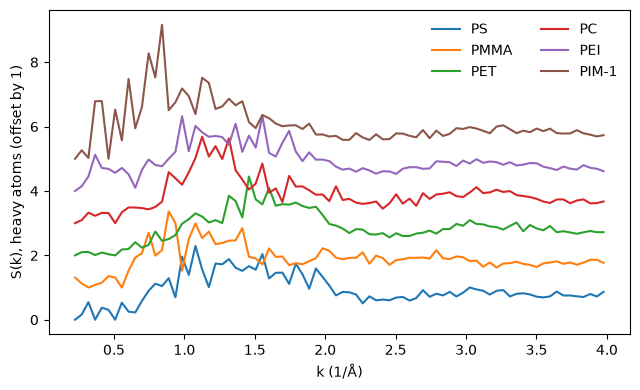

In [12]:
import freud
import matplotlib.pyplot as plt

K_MIN, K_MAX, BINS = 0.2, 4.0, 80     # 1/A

fig, ax = plt.subplots(figsize=(6.5, 4))
for offset, (name, melt) in enumerate(melts.items()):
    heavy = melt.select_atoms("not element H")
    box = freud.box.Box.from_box(melt.dimensions[:3])
    sf = freud.diffraction.StaticStructureFactorDirect(bins=BINS, k_max=K_MAX, k_min=K_MIN)
    sf.compute((box, box.wrap(heavy.positions)))
    valid = np.isfinite(sf.S_k) & (sf.bin_centers >= sf.min_valid_k)
    ax.plot(sf.bin_centers[valid], sf.S_k[valid] + offset, label=name)
ax.set_xlabel("k (1/Å)")
ax.set_ylabel("S(k), heavy atoms (offset by 1)")
ax.legend(frameon=False, ncol=2)
fig.tight_layout()

## For further analysis

* **Files.** `outputs/4-colina-polymers/<name>/minimized.pdb` loads in
  MDAnalysis, MDTraj, OVITO, VMD and PyMOL. Chains are segments
  (`segid 0000` ... ), monomers are residues, and CONECT holds every bond.
* **Selections.** `melt.select_atoms("resname PSR")` picks R monomers of
  PS; `melt.segments[i]` is chain i; `melt.atoms.fragments` recovers
  molecules from the bonds alone.
* **Movies.** `cd outputs/4-colina-polymers/<name> && pymol movie.pml` loads
  the DPD trajectory with carbons colored by chain; the rendering commands
  are at the end of the script.
* **Bigger or more systems.** Change `CHEMISTRIES` (repeats, chains) and the
  `seed`; the PDB writer handles up to 99,999 atoms per file and 1.68
  million molecules.
* **Equilibrium properties.** Run NPT MD from `minimized.pdb` with the same
  Sage 2.3.0 parameters (`phantomwalk.all_atom.build_sage_interchange`
  builds the Interchange) before comparing density, Rg or WAXS with
  experiment.